In [1]:
print("Notebook is working")

Notebook is working


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trader Data Shape:", trades.shape)
print("Sentiment Data Shape:", sentiment.shape)

Trader Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


In [4]:
print("=== TRADES DATA ===")
display(trades.head())

print("\nColumns:")
print(trades.columns.tolist())

print("\n=== SENTIMENT DATA ===")
display(sentiment.head())

print("\nColumns:")
print(sentiment.columns.tolist())

=== TRADES DATA ===


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

=== SENTIMENT DATA ===


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Columns:
['timestamp', 'value', 'classification', 'date']


In [5]:
print("TRADES MISSING VALUES")
print(trades.isnull().sum())

print("\nSENTIMENT MISSING VALUES")
print(sentiment.isnull().sum())

TRADES MISSING VALUES
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

SENTIMENT MISSING VALUES
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [6]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['trade_date'] = trades['Timestamp'].dt.date

sentiment['trade_date'] = sentiment['date'].dt.date

print("Date conversion completed")

Date conversion completed


In [7]:
merged = pd.merge(
    trades,
    sentiment[['trade_date', 'classification']],
    on='trade_date',
    how='left'
)

print("Merged Shape:", merged.shape)

display(
    merged[
        ['Coin',
         'Closed PnL',
         'Side',
         'classification']
    ].head()
)

Merged Shape: (211224, 18)


,Coin,Closed PnL,Side,classification
0,@107,0.0,BUY,NaN
1,@107,0.0,BUY,NaN
2,@107,0.0,BUY,NaN
3,@107,0.0,BUY,NaN
4,@107,0.0,BUY,NaN


In [8]:
print("Trades Date Range")
print(trades['trade_date'].min())
print(trades['trade_date'].max())

print("\nSentiment Date Range")
print(sentiment['trade_date'].min())
print(sentiment['trade_date'].max())

Trades Date Range
1970-01-01
1970-01-01

Sentiment Date Range
2018-02-01
2025-05-02


In [9]:
print("Missing classifications:")
print(merged['classification'].isna().sum())

print("Total rows:")
print(len(merged))

Missing classifications:
211224
Total rows:
211224


In [10]:
print(trades['Timestamp'].head())

0   1970-01-01 00:28:50
1   1970-01-01 00:28:50
2   1970-01-01 00:28:50
3   1970-01-01 00:28:50
4   1970-01-01 00:28:50
Name: Timestamp, dtype: datetime64[ns]


In [11]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

trades['trade_date'] = trades['Timestamp'].dt.date

print(trades['trade_date'].min())
print(trades['trade_date'].max())

1970-01-01
1970-01-01


In [12]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='s')

trades['trade_date'] = trades['Timestamp'].dt.date

print(trades['trade_date'].min())
print(trades['trade_date'].max())

1970-01-01
1970-01-01


In [13]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['trade_date'] = trades['Timestamp IST'].dt.date

print(trades['trade_date'].min())
print(trades['trade_date'].max())

2023-05-01
2025-05-01


In [14]:
merged = pd.merge(
    trades,
    sentiment[['trade_date', 'classification']],
    on='trade_date',
    how='left'
)

print("Missing classifications:",
      merged['classification'].isna().sum())

print("Total rows:",
      len(merged))

Missing classifications: 6
Total rows: 211224


In [15]:
merged['win'] = merged['Closed PnL'] > 0

In [16]:
summary = merged.groupby('classification').agg(
    Avg_PnL=('Closed PnL','mean'),
    Median_PnL=('Closed PnL','median'),
    Win_Rate=('win','mean'),
    Avg_Trade_Size=('Size USD','mean'),
    Avg_Fee=('Fee','mean')
).round(2)

summary['Win_Rate'] = summary['Win_Rate'] * 100

summary.sort_values('Avg_PnL', ascending=False)

,Avg_PnL,Median_PnL,Win_Rate,Avg_Trade_Size,Avg_Fee
classification,,,,,
Extreme Greed,67.89,0.0,46.0,3112.25,0.68
Fear,54.29,0.0,42.0,7816.11,1.50
Greed,42.74,0.0,38.0,5736.88,1.25
Extreme Fear,34.54,0.0,37.0,5349.73,1.12
Neutral,34.31,0.0,40.0,4782.73,1.04


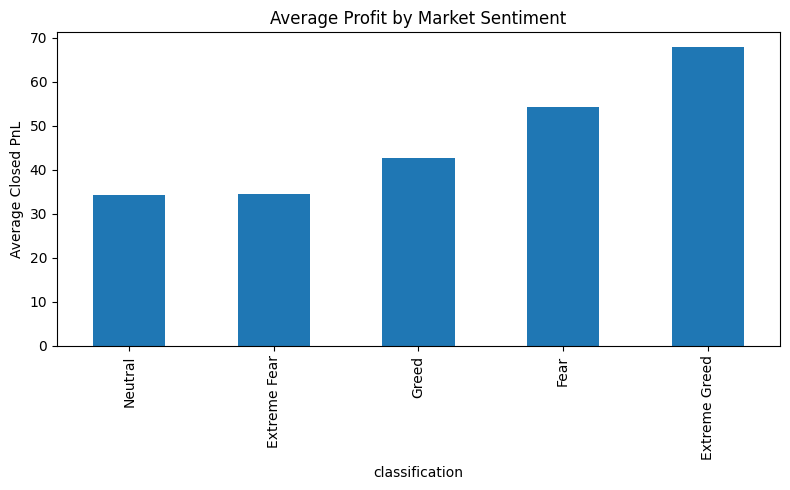

In [17]:
plt.figure(figsize=(8,5))

merged.groupby('classification')['Closed PnL'].mean().sort_values().plot(
    kind='bar'
)

plt.title('Average Profit by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.tight_layout()

plt.show()

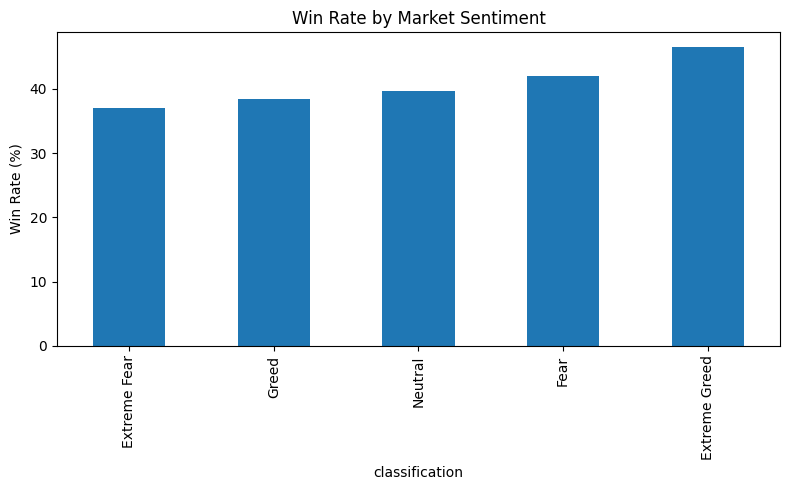

In [18]:
win_rate = merged.groupby('classification')['win'].mean() * 100

plt.figure(figsize=(8,5))

win_rate.sort_values().plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.tight_layout()

plt.show()

In [19]:
side_analysis = pd.crosstab(
    merged['classification'],
    merged['Side']
)

display(side_analysis)

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [20]:
coin_analysis = merged.groupby('Coin').agg(
    Avg_PnL=('Closed PnL','mean'),
    Trades=('Coin','count')
)

coin_analysis = coin_analysis.sort_values(
    'Avg_PnL',
    ascending=False
)

coin_analysis.head(10)

,Avg_PnL,Trades
Coin,,
@109,270.704207,20
AVAX,239.095613,202
ENA,219.524751,990
@85,200.804091,132
EIGEN,197.063189,330
PEOPLE,180.323003,2
DOGE,178.623676,826
SOL,153.358519,10691
MOODENG,151.096714,107


In [21]:
coin_analysis_filtered = merged.groupby('Coin').agg(
    Avg_PnL=('Closed PnL','mean'),
    Trades=('Coin','count')
)

coin_analysis_filtered = coin_analysis_filtered[
    coin_analysis_filtered['Trades'] >= 100
]

coin_analysis_filtered.sort_values(
    'Avg_PnL',
    ascending=False
).head(10)

,Avg_PnL,Trades
Coin,,
AVAX,239.095613,202
ENA,219.524751,990
@85,200.804091,132
EIGEN,197.063189,330
DOGE,178.623676,826
SOL,153.358519,10691
MOODENG,151.096714,107
ZRO,148.327509,1239
ETHFI,141.250823,311


# Key Findings

1. Extreme Greed delivered the highest average profit per trade (67.89) and the highest win rate (46%), making it the strongest sentiment condition for trader performance.

2. Extreme Fear generated lower profitability (34.54) and a lower win rate (37%), indicating weaker trading outcomes during negative market sentiment.

3. Trader profitability increased as market sentiment improved from Fear to Greed, suggesting a positive relationship between sentiment and trading performance.

4. Extreme Greed periods achieved superior results despite smaller average trade sizes, indicating that disciplined position sizing may be more effective than increasing exposure.

5. Trading activity varied across sentiment conditions, demonstrating that trader behavior changes in response to market psychology.

6. Among assets with at least 100 trades, AVAX, ENA, EIGEN, DOGE, and SOL were among the strongest performers based on average Closed PnL.

# Recommendations

* Incorporate market sentiment as an additional signal when evaluating trading opportunities.

* Reduce risk exposure during Fear and Extreme Fear conditions where profitability and win rates tend to be lower.

* Focus on disciplined position sizing instead of aggressively increasing trade size during volatile periods.

* Monitor assets that demonstrate consistent profitability across different market conditions.

* Combine sentiment indicators with technical and quantitative analysis to improve decision-making and risk management.

# Conclusion

This analysis demonstrates a clear relationship between Bitcoin market sentiment and trader performance. Positive sentiment conditions, particularly Extreme Greed, were associated with higher profitability and improved win rates. The results suggest that market sentiment can be a valuable supplementary indicator for trading strategy development, risk management, and asset selection.
